In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vernandikahansen/manual-test1/chh2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test1/husky2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test1/husky1.jpg
/kaggle/input/datasets/vernandikahansen/manual-test1/beatzu.jpg
/kaggle/input/datasets/vernandikahansen/manual-test1/chh.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/chh2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/husky2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/husky1.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/malamute.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/beatzu.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/alusky.jpg
/kaggle/input/datasets/vernandikahansen/manual-test5/chh.jpg
/kaggle/input/datasets/vernandikahansen/manual-test3/chh2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test3/husky2.jpg
/kaggle/input/datasets/vernandikahansen/manual-test3/husky1.jpg
/kaggle/input/datasets/vernandikahansen/manual-tes

In [2]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import shutil
import random

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import seaborn as sns

2026-05-04 06:03:56.873794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777874637.068230      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777874637.124323      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777874637.584430      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777874637.584470      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777874637.584473      57 computation_placer.cc:177] computation placer alr

In [3]:
# 1. Tentukan Path Sumber (Dataset Kaggle) dan Path Tujuan (Folder Kerja)
source_path = '/kaggle/input/datasets/vikaschauhan734/120-dog-breed-image-classification/images'
working_path = '/kaggle/working/dog_breed_selection'

# 2. Daftar 15 Ras Anjing yang Dipilih untuk Penelitian
selected_breeds = [
    'Siberian_husky', 'malamute', 'golden_retriever', 'Labrador_retriever', 
    'beagle', 'German_shepherd', 'boxer', 'pug', 'French_bulldog', 
    'Chihuahua', 'Samoyed', 'Doberman', 'Rottweiler', 
    'cocker_spaniel', 'Shih-Tzu'
]

# 3. Hapus folder jika sudah ada (agar bersih saat Run All)
if os.path.exists(working_path):
    shutil.rmtree(working_path)
os.makedirs(working_path)

# 4. Proses Undersampling: Ambil tepat 150 gambar secara acak per ras
print("Memulai proses seleksi dataset (150 gambar per ras)...")

for breed in selected_breeds:
    breed_source = os.path.join(source_path, breed)
    
    # PROTEKSI: Cek apakah folder sumber benar-benar ada
    if not os.path.exists(breed_source):
        print(f"Peringatan: Folder {breed} tidak ditemukan di sumber! Melewati...")
        continue
        
    # LOGIKA PERBAIKAN: Cek tanda hubung agar tidak IndexError
    if '-' in breed:
        folder_name = breed.split('-', 1)[1].lower()
    else:
        folder_name = breed.lower()
        
    breed_dest = os.path.join(working_path, folder_name)
    os.makedirs(breed_dest, exist_ok=True)
    
    # Ambil gambar
    all_images = os.listdir(breed_source)
    
    # Ambil 150 atau jumlah maksimal yang tersedia jika kurang dari 150
    num_to_sample = min(len(all_images), 150)
    sampled_images = random.sample(all_images, num_to_sample)
    
    for img_name in sampled_images:
        shutil.copy(os.path.join(breed_source, img_name), os.path.join(breed_dest, img_name))

print(f"\nSelesai! Dataset tersimpan di: {working_path}")
print(f"Total folder ras yang berhasil dibuat: {len(os.listdir(working_path))}")

Memulai proses seleksi dataset (150 gambar per ras)...

Selesai! Dataset tersimpan di: /kaggle/working/dog_breed_selection
Total folder ras yang berhasil dibuat: 15


In [4]:
def build_mobilenet_v2(num_classes=15):
    """
    Fungsi untuk membangun model MobileNetV2 dengan Transfer Learning.
    Menggunakan pre-trained weights dari ImageNet.
    """
    # 1. Load Base Model (Tanpa Top Layer/Kepala Klasifikasi)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # 2. Freeze Base Model (Membekukan bobot agar tidak berubah saat awal training)
    base_model.trainable = False
    
    # 3. Menyusun Arsitektur Klasifikasi Baru
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Meringkas fitur visual menjadi vektor
        layers.Dropout(0.2),             # Regulasi untuk mencegah overfitting
        layers.Dense(num_classes, activation='softmax') # Output layer 15 ras anjing
    ])
    
    return model

def build_efficientnet_b0(num_classes=15):
    """
    Fungsi untuk membangun model EfficientNet-B0 dengan Transfer Learning.
    Arsitektur ini memiliki efisiensi scaling yang lebih baik.
    """
    # 1. Load Base Model EfficientNet-B0
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # 2. Freeze Base Model
    base_model.trainable = False
    
    # 3. Menyusun Arsitektur Klasifikasi Baru
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),             # Nilai dropout disamakan (0.2) sesuai revisi Bab 3
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Inisialisasi Model untuk pengecekan summary (Opsional)
model_test_mobile = build_mobilenet_v2()
model_test_eff = build_efficientnet_b0()

print("Arsitektur MobileNetV2 dan EfficientNet-B0 berhasil didefinisikan.")
print(f"Total Parameter MobileNetV2: {model_test_mobile.count_params():,}")
print(f"Total Parameter EfficientNet-B0: {model_test_eff.count_params():,}")

I0000 00:00:1777874670.815078      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777874670.821523      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Arsitektur MobileNetV2 dan EfficientNet-B0 berhasil didefinisikan.
Total Parameter MobileNetV2: 2,277,199
Total Parameter EfficientNet-B0: 4,068,786


In [5]:
# 1. Konfigurasi Augmentasi (Parameter disamakan untuk keadilan komparasi)
# Augmentasi hanya diterapkan pada DATA TRAIN
train_aug_config = {
    'rotation_range': 20,      # Memutar gambar hingga 20 derajat
    'width_shift_range': 0.2,  # Menggeser gambar secara horizontal
    'height_shift_range': 0.2, # Menggeser gambar secara vertikal
    'shear_range': 0.2,        # Meregangkan gambar secara diagonal
    'zoom_range': 0.2,         # Melakukan zoom in/out
    'horizontal_flip': True,   # Membalik gambar secara horizontal
    'fill_mode': 'nearest',    # Mengisi piksel kosong akibat transformasi
    'validation_split': 0.2    # Membagi 20% data untuk validasi
}

# 2. Generator Khusus MobileNetV2 (WAJIB RESCALE 1./255)
mobilenet_datagen = ImageDataGenerator(rescale=1./255, **train_aug_config)
mobilenet_val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# 3. Generator Khusus EfficientNet-B0 (TANPA RESCALE - Menggunakan Internal Preprocessing)
effnet_datagen = ImageDataGenerator(**train_aug_config)
effnet_val_datagen = ImageDataGenerator(validation_split=0.2)

# --- LOADING DATA UNTUK MOBILENETV2 ---
train_gen_mobile = mobilenet_datagen.flow_from_directory(
    working_path, target_size=(224, 224), batch_size=32, 
    class_mode='categorical', subset='training', seed=42
)

val_gen_mobile = mobilenet_val_datagen.flow_from_directory(
    working_path, target_size=(224, 224), batch_size=32, 
    class_mode='categorical', subset='validation', seed=42
)

# --- LOADING DATA UNTUK EFFICIENTNET-B0 ---
train_gen_eff = effnet_datagen.flow_from_directory(
    working_path, target_size=(224, 224), batch_size=32, 
    class_mode='categorical', subset='training', seed=42
)

val_gen_eff = effnet_val_datagen.flow_from_directory(
    working_path, target_size=(224, 224), batch_size=32, 
    class_mode='categorical', subset='validation', seed=42
)

print(f"\nPersiapan Data Selesai:")
print(f"MobileNet: {train_gen_mobile.samples} training, {val_gen_mobile.samples} validation")
print(f"EfficientNet: {train_gen_eff.samples} training, {val_gen_eff.samples} validation")

Found 1800 images belonging to 15 classes.
Found 450 images belonging to 15 classes.
Found 1800 images belonging to 15 classes.
Found 450 images belonging to 15 classes.

Persiapan Data Selesai:
MobileNet: 1800 training, 450 validation
EfficientNet: 1800 training, 450 validation


In [6]:
# Tambahkan ini sebelum membangun model
tf.keras.backend.clear_session()

# 1. Inisialisasi Model dari Fungsi di Sel 3
model_mobilenet = build_mobilenet_v2()
model_efficientnet = build_efficientnet_b0()

# 2. Definisi Metrik
top3_metric = tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')

# 3. Kompilasi MobileNetV2 (Gunakan optimizer baru khusus mobile)
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', top3_metric]
)

# 4. Kompilasi EfficientNet-B0 (Gunakan optimizer baru khusus effnet)
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', top3_metric]
)

# 5. Konfigurasi Callbacks
# EarlyStopping: Berhenti jika val_loss tidak turun selama 5 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ModelCheckpoint: Simpan hanya model dengan akurasi validasi terbaik
checkpoint_mobile = ModelCheckpoint('best_mobilenet.keras', monitor='val_accuracy', save_best_only=True)
checkpoint_eff = ModelCheckpoint('best_efficientnet.keras', monitor='val_accuracy', save_best_only=True)

# --- PROSES PELATIHAN ---

print("\n--- Memulai Pelatihan MobileNetV2 ---")
history_mobile = model_mobilenet.fit(
    train_gen_mobile,
    validation_data=val_gen_mobile,
    epochs=50,
    callbacks=[early_stop, checkpoint_mobile]
)

print("\n--- Memulai Pelatihan EfficientNet-B0 ---")
history_eff = model_efficientnet.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=50,
    callbacks=[early_stop, checkpoint_eff]
)

print("\nPelatihan selesai dan model terbaik telah disimpan!")


--- Memulai Pelatihan MobileNetV2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1777874682.591541     130 service.cc:152] XLA service 0x7f95b0004c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777874682.591597     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777874682.591604     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777874683.587499     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-04 06:04:52.237249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:04:52.374939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777874694.507990     130 device_co

 7/57 ━━━━━━━━━━━━━━━━━━━━ 15s 302ms/step - accuracy: 0.0430 - loss: 3.2727 - top_3_accuracy: 0.1468

...

54/57 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.0903 - loss: 2.7162 - top_3_accuracy: 0.5621

2026-05-04 06:23:49.296289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:23:49.431375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:23:49.732861: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:23:49.872086: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:23:50.632101: E external/local_xla/xla/stream_

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.0928 - loss: 2.7105 - top_3_accuracy: 0.5572

2026-05-04 06:24:07.529790: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:24:07.662914: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:24:07.963591: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:24:08.103470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:24:08.852384: E external/local_xla/xla/stream_

57/57 ━━━━━━━━━━━━━━━━━━━━ 70s 839ms/step - accuracy: 0.0936 - loss: 2.7087 - top_3_accuracy: 0.5557 - val_accuracy: 0.3244 - val_loss: 2.3129 - val_top_3_accuracy: 0.6333
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 381ms/step - accuracy: 0.3104 - loss: 2.2804 - top_3_accuracy: 0.6149 - val_accuracy: 0.6467 - val_loss: 1.8881 - val_top_3_accuracy: 0.8822
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 378ms/step - accuracy: 0.5763 - loss: 1.8633 - top_3_accuracy: 0.8706 - val_accuracy: 0.7800 - val_loss: 1.5449 - val_top_3_accuracy: 0.9644
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 383ms/step - accuracy: 0.7021 - loss: 1.5805 - top_3_accuracy: 0.9400 - val_accuracy: 0.8378 - val_loss: 1.2716 - val_top_3_accuracy: 0.9778
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 379ms/step - accuracy: 0.7782 - loss: 1.3318 - top_3_accuracy: 0.9614 - val_accuracy: 0.8711 - val_loss: 1.0619 - val_top_3_accuracy: 0.9867
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 378ms/step - accuracy: 0.8253 - loss: 1.1324 - top_3_a


--- Visualisasi Performa MobileNetV2 ---


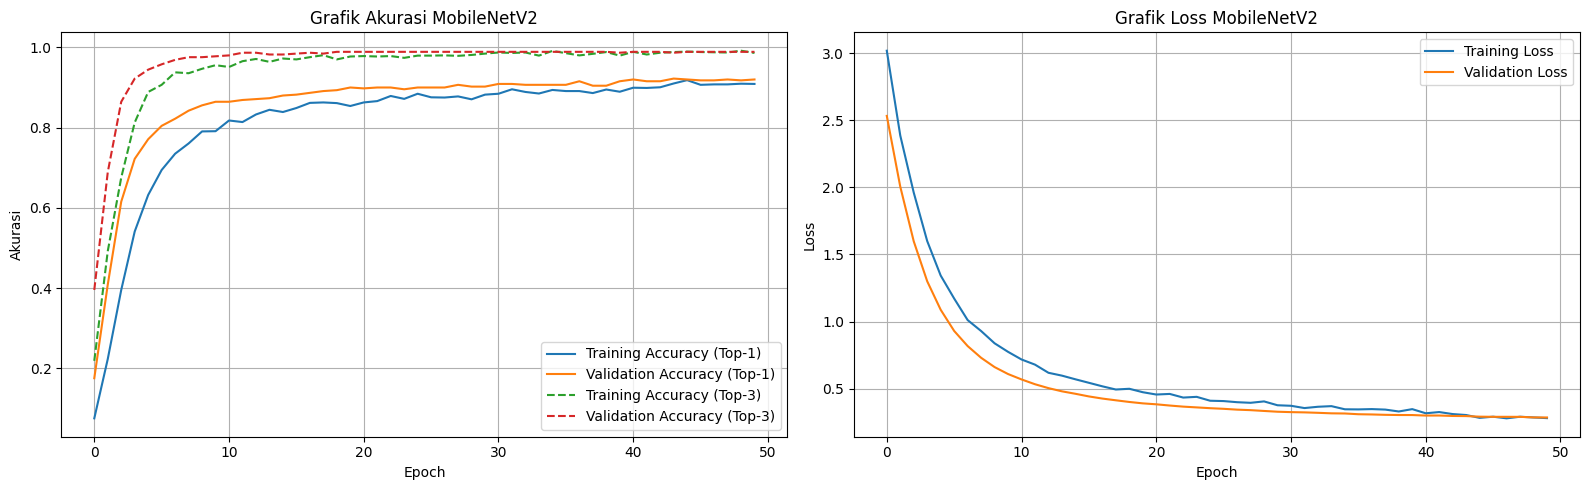


--- Visualisasi Performa EfficientNet-B0 ---


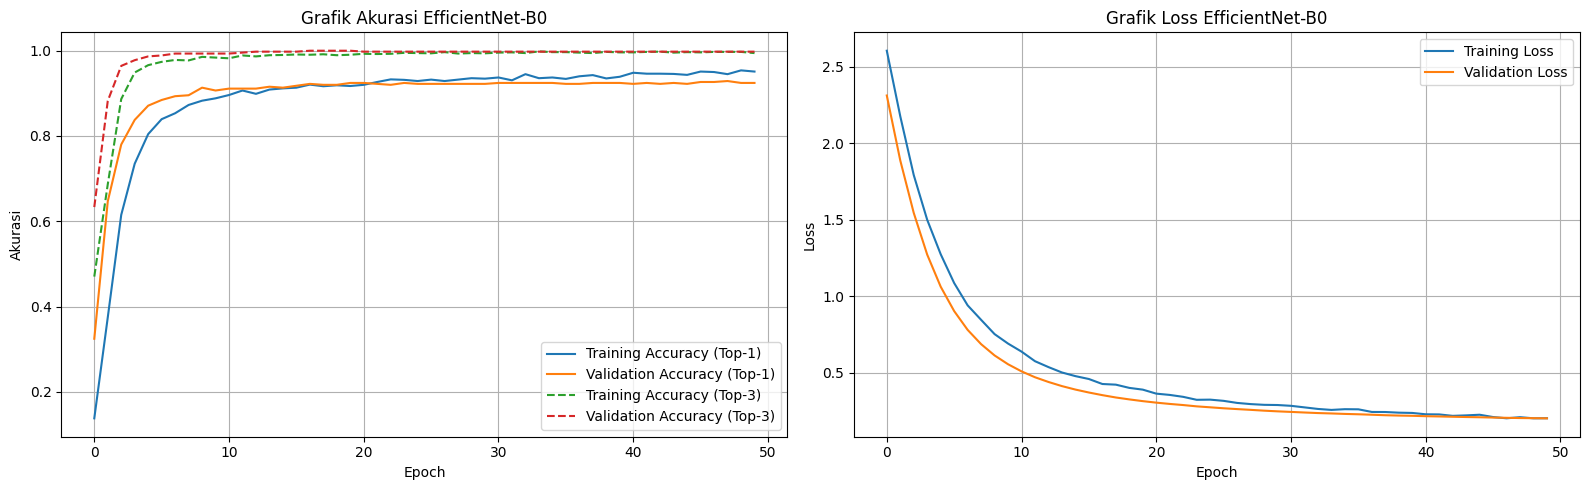


METRIK               | MOBILENETV2 | EFFICIENTNET
----------------------------------------
Val Accuracy (Top-1) |      92.22% |      92.89%
Val Accuracy (Top-3) |      98.89% |     100.00%


In [7]:
def plot_training_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    top3_acc = history.history['top_3_accuracy']
    val_top3_acc = history.history['val_top_3_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 5))

    # Grafik Akurasi (Top-1 vs Top-3)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy (Top-1)')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy (Top-1)')
    plt.plot(epochs_range, top3_acc, label='Training Accuracy (Top-3)', linestyle='--')
    plt.plot(epochs_range, val_top3_acc, label='Validation Accuracy (Top-3)', linestyle='--')
    plt.title(f'Grafik Akurasi {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'Grafik Loss {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# --- 1. Visualisasi Performa MobileNetV2 ---
print("\n--- Visualisasi Performa MobileNetV2 ---")
plot_training_history(history_mobile, "MobileNetV2")

# --- 2. Visualisasi Performa EfficientNet-B0 ---
print("\n--- Visualisasi Performa EfficientNet-B0 ---")
plot_training_history(history_eff, "EfficientNet-B0")

# --- 3. Tabel Ringkasan Final ---
print("\n" + "="*40)
print(f"{'METRIK':<20} | {'MOBILENETV2':<10} | {'EFFICIENTNET'}")
print("-" * 40)

def get_best_metrics(history):
    # Mengambil nilai terbaik dari history
    best_acc = max(history.history['val_accuracy'])
    best_top3 = max(history.history['val_top_3_accuracy'])
    return best_acc, best_top3

m_acc, m_top3 = get_best_metrics(history_mobile)
e_acc, e_top3 = get_best_metrics(history_eff)

print(f"{'Val Accuracy (Top-1)':<20} | {m_acc*100:>10.2f}% | {e_acc*100:>10.2f}%")
print(f"{'Val Accuracy (Top-3)':<20} | {m_top3*100:>10.2f}% | {e_top3*100:>10.2f}%")
print("="*40)

2026-05-04 06:41:29.576239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:41:29.710503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:41:30.447885: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:41:30.582486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


2026-05-04 06:41:39.928122: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 06:41:40.070025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


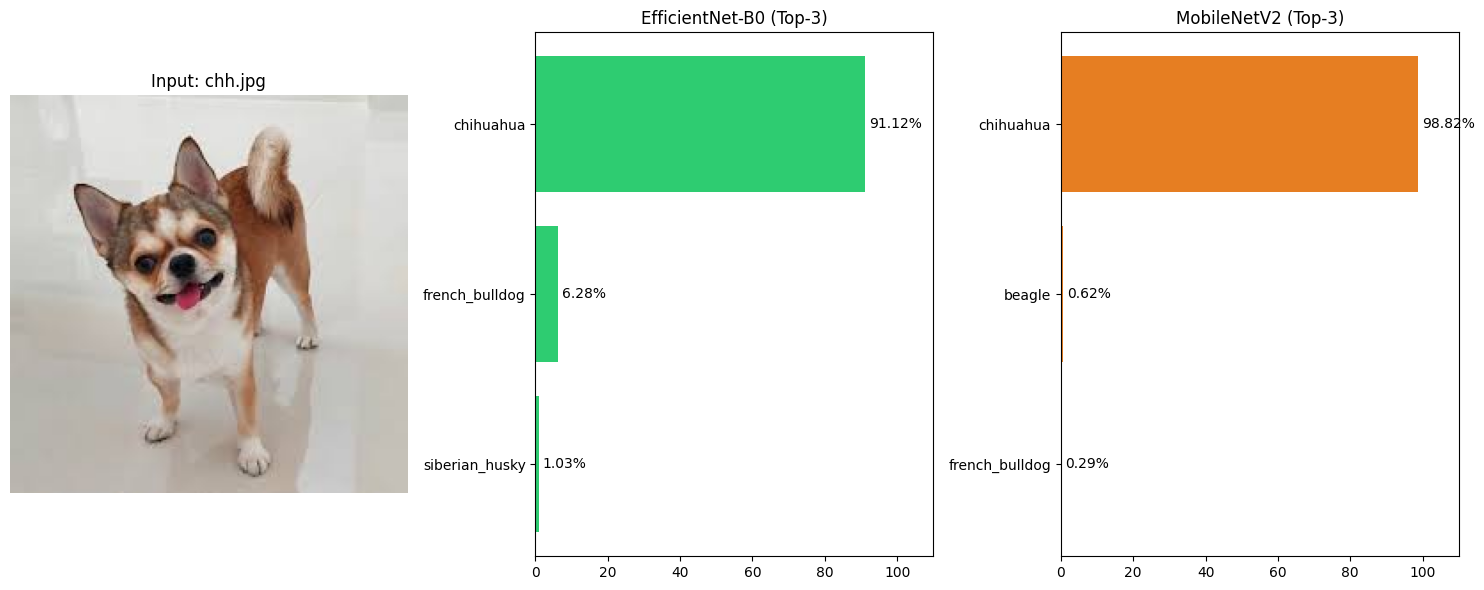

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


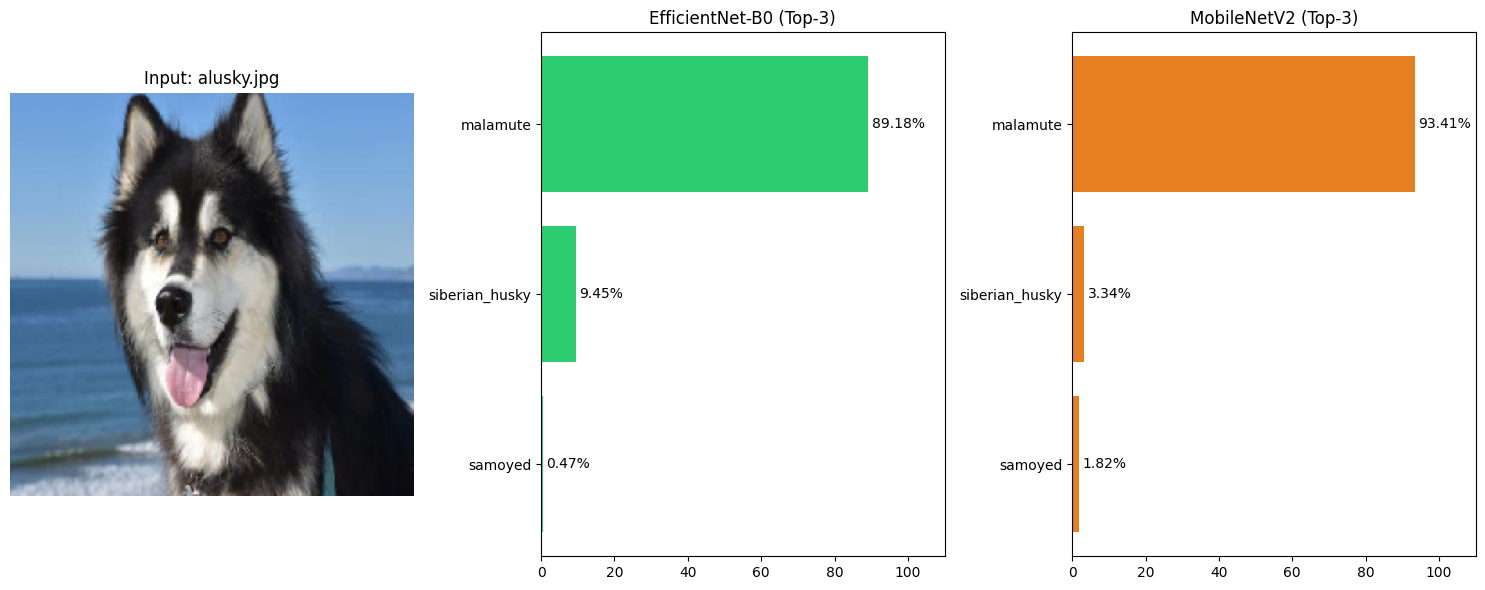

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


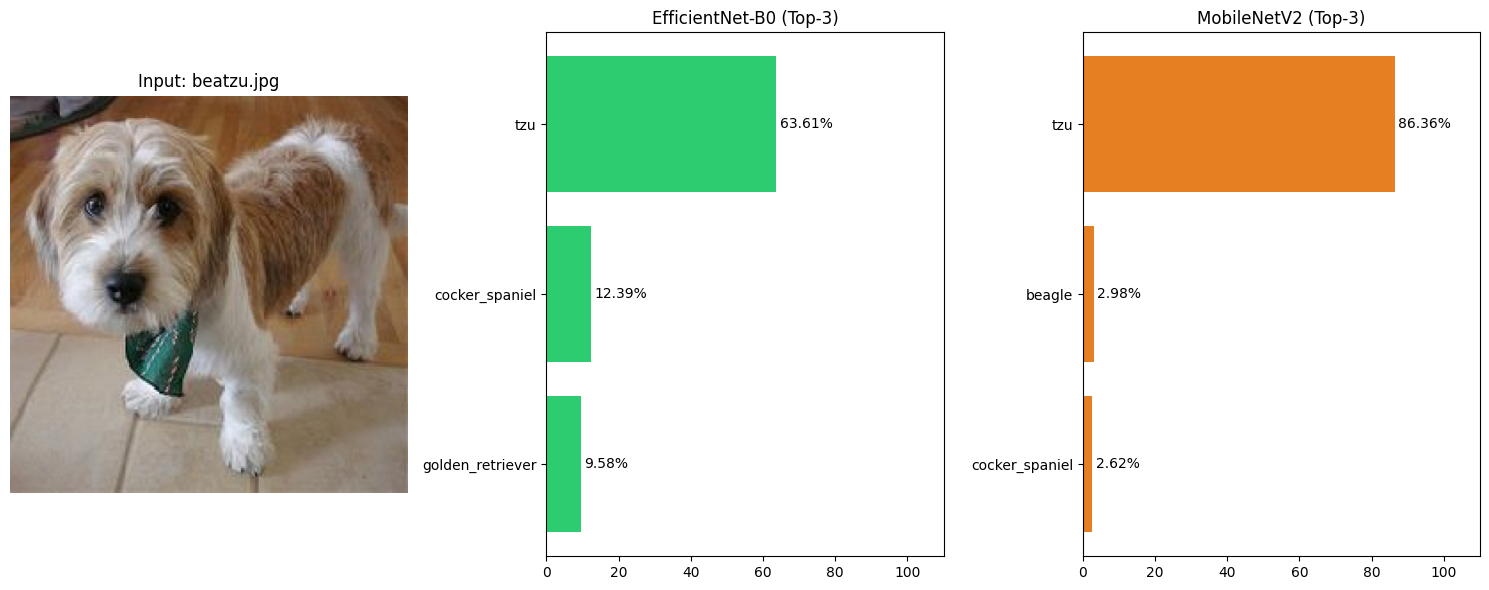

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


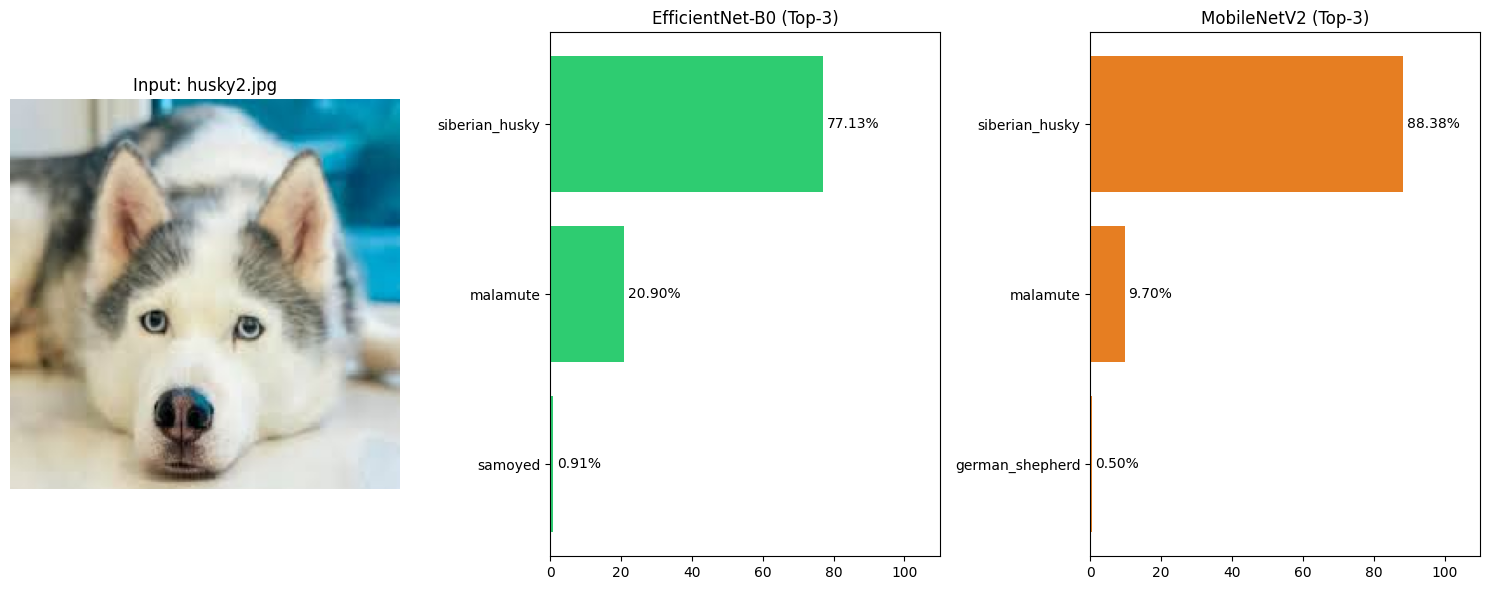

In [8]:
def compare_inference(img_path):
    # 1. Load dan Preprocessing Gambar
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # 2. Prediksi EfficientNet-B0 (Tanpa Rescale)
    # Pastikan variabel model_efficientnet merujuk pada model terbaik yang sudah dimuat
    preds_eff = model_efficientnet.predict(img_array)
    
    # 3. Prediksi MobileNetV2 (Wajib Rescale 1./255)
    img_array_mobile = img_array / 255.0
    preds_mobile = model_mobilenet.predict(img_array_mobile)
    
    # 4. Ambil Nama Kelas
    classes = sorted(os.listdir(working_path))
    
    # Ambil Top-3 Indices
    top3_eff = np.argsort(preds_eff[0])[-3:][::-1]
    top3_mobile = np.argsort(preds_mobile[0])[-3:][::-1]
    
    # 5. Visualisasi Perbandingan
    plt.figure(figsize=(15, 6))
    
    # Tampilkan Gambar Asli
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Input: {img_path.split('/')[-1]}")
    
    # Bar Chart EfficientNet-B0
    plt.subplot(1, 3, 2)
    names_eff = [classes[i] for i in top3_eff]
    probs_eff = [preds_eff[0][i] * 100 for i in top3_eff]
    bars_eff = plt.barh(names_eff, probs_eff, color='#2ecc71')
    plt.xlim(0, 110)
    plt.title('EfficientNet-B0 (Top-3)')
    plt.gca().invert_yaxis()
    for bar in bars_eff:
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2f}%', va='center')

    # Bar Chart MobileNetV2
    plt.subplot(1, 3, 3)
    names_mobile = [classes[i] for i in top3_mobile]
    probs_mobile = [preds_mobile[0][i] * 100 for i in top3_mobile]
    bars_mobile = plt.barh(names_mobile, probs_mobile, color='#e67e22')
    plt.xlim(0, 110)
    plt.title('MobileNetV2 (Top-3)')
    plt.gca().invert_yaxis()
    for bar in bars_mobile:
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2f}%', va='center')

    plt.tight_layout()
    plt.show()

# Masukkan path gambar yang ingin Anda uji di sini
test_image_path = '/kaggle/input/datasets/vernandikahansen/manual-test5/chh.jpg'
compare_inference(test_image_path)

test_image_path2 = '/kaggle/input/datasets/vernandikahansen/manual-test5/alusky.jpg'
compare_inference(test_image_path2)

test_image_path3 = '/kaggle/input/datasets/vernandikahansen/manual-test5/beatzu.jpg'
compare_inference(test_image_path3)

test_image_path4 = '/kaggle/input/datasets/vernandikahansen/manual-test5/husky2.jpg'
compare_inference(test_image_path4)

Menghitung metrik evaluasi untuk MobileNetV2...
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step

--- Classification Report: MobileNetV2 ---
                    precision    recall  f1-score   support

            beagle       0.03      0.03      0.03        30
             boxer       0.12      0.13      0.13        30
         chihuahua       0.03      0.03      0.03        30
    cocker_spaniel       0.03      0.03      0.03        30
          doberman       0.00      0.00      0.00        30
    french_bulldog       0.03      0.03      0.03        30
   german_shepherd       0.14      0.13      0.14        30
  golden_retriever       0.07      0.07      0.07        30
labrador_retriever       0.00      0.00      0.00        30
          malamute       0.03      0.03      0.03        30
               pug       0.00      0.00      0.00        30
        rottweiler       0.07      0.07      0.07        30
           samoyed       0.07      0.07      0.07        30
    siberian_husky       0

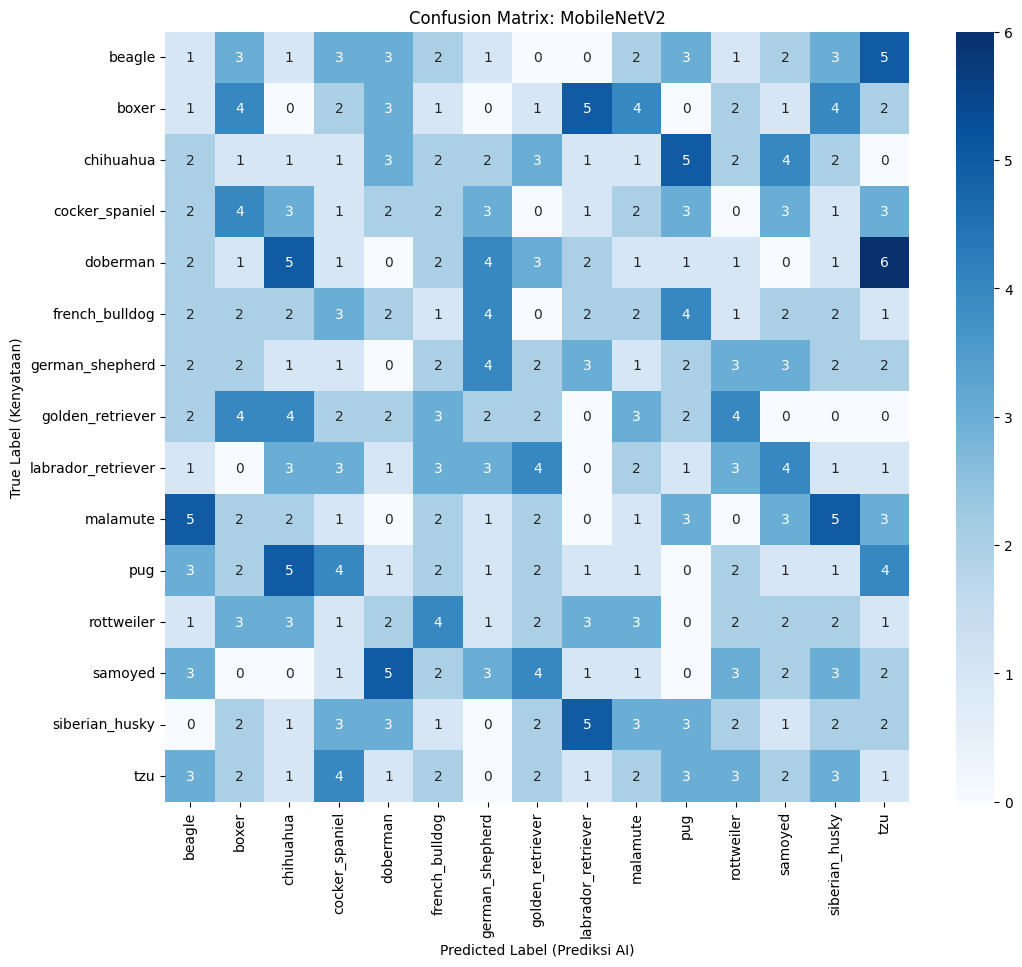

Menghitung metrik evaluasi untuk EfficientNet-B0...
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 537ms/step

--- Classification Report: EfficientNet-B0 ---
                    precision    recall  f1-score   support

            beagle       0.03      0.03      0.03        30
             boxer       0.10      0.10      0.10        30
         chihuahua       0.03      0.03      0.03        30
    cocker_spaniel       0.03      0.03      0.03        30
          doberman       0.00      0.00      0.00        30
    french_bulldog       0.03      0.03      0.03        30
   german_shepherd       0.13      0.13      0.13        30
  golden_retriever       0.09      0.10      0.10        30
labrador_retriever       0.00      0.00      0.00        30
          malamute       0.06      0.07      0.07        30
               pug       0.00      0.00      0.00        30
        rottweiler       0.07      0.07      0.07        30
           samoyed       0.06      0.07      0.06        30
    siberian_husk

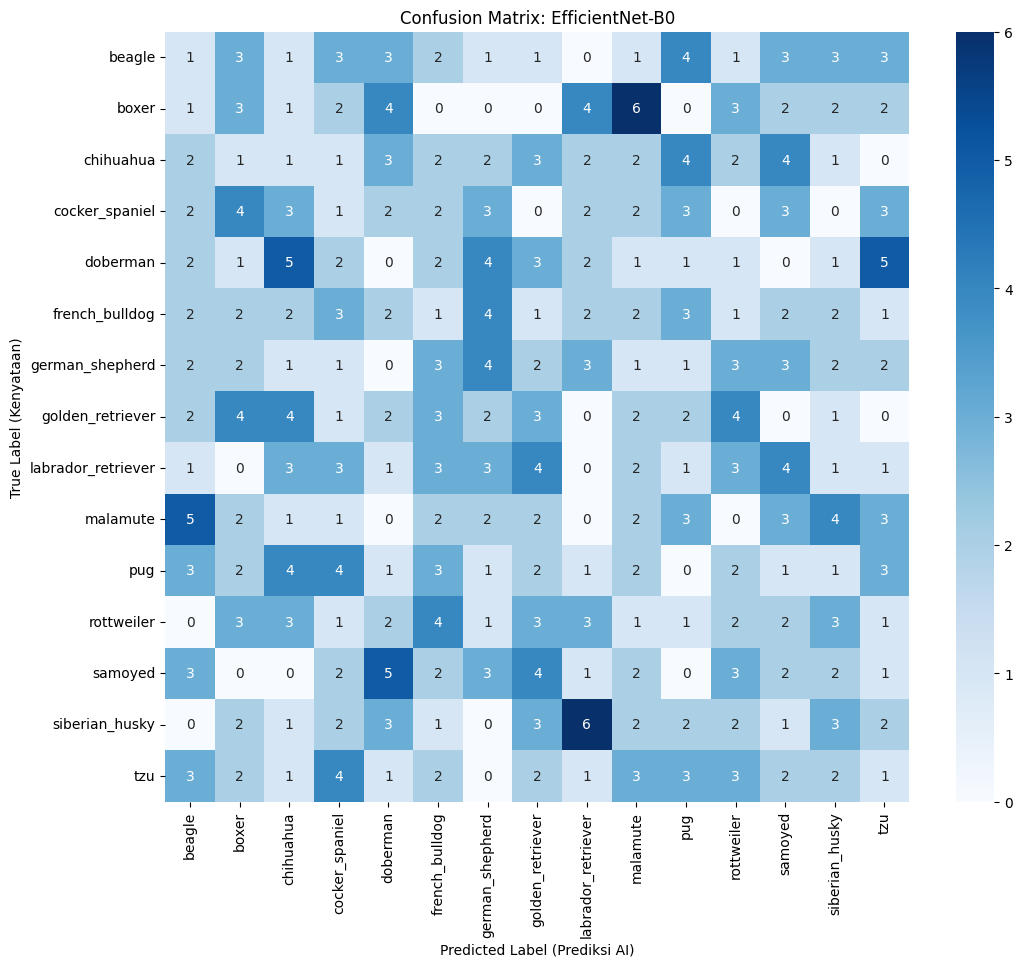

In [9]:
def evaluate_full_metrics(model, generator, model_name):
    # 1. Reset generator agar urutan data konsisten
    generator.reset()
    
    # 2. Prediksi seluruh data validasi
    print(f"Menghitung metrik evaluasi untuk {model_name}...")
    Y_pred = model.predict(generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # 3. Cetak Classification Report (Precision, Recall, F1-Score)
    print(f"\n--- Classification Report: {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # 4. Visualisasi Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label (Kenyataan)')
    plt.xlabel('Predicted Label (Prediksi AI)')
    plt.show()

# --- EVALUASI MOBILENETV2 ---
evaluate_full_metrics(model_mobilenet, val_gen_mobile, "MobileNetV2")

# --- EVALUASI EFFICIENTNET-B0 ---
evaluate_full_metrics(model_efficientnet, val_gen_eff, "EfficientNet-B0")

Found 1800 images belonging to 15 classes.
Found 450 images belonging to 15 classes.

--- Membangun Model EfficientNet-B0 (Tanpa Augmentasi) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.0715 - loss: 2.8005 - val_accuracy: 0.2733 - val_loss: 2.3733
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.3396 - loss: 2.2610 - val_accuracy: 0.5978 - val_loss: 1.9114
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6275 - loss: 1.8555 - val_accuracy: 0.7733 - val_loss: 1.5410
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.7754 - loss: 1.5004 - val_accuracy: 0.8422 - val_loss: 1.2555
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8380 - loss: 1.2320 - val_accuracy: 0.8689 - val_loss: 1.0406
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8644 - loss: 1.0476 - val_accuracy: 0.8822 - val_loss: 0.8786
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8895 - loss: 0.8719 - val_accuracy: 0.8889 - val_loss: 0.7566
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9113 - loss: 0.7315 - val_accuracy: 0.8933 - val_loss: 

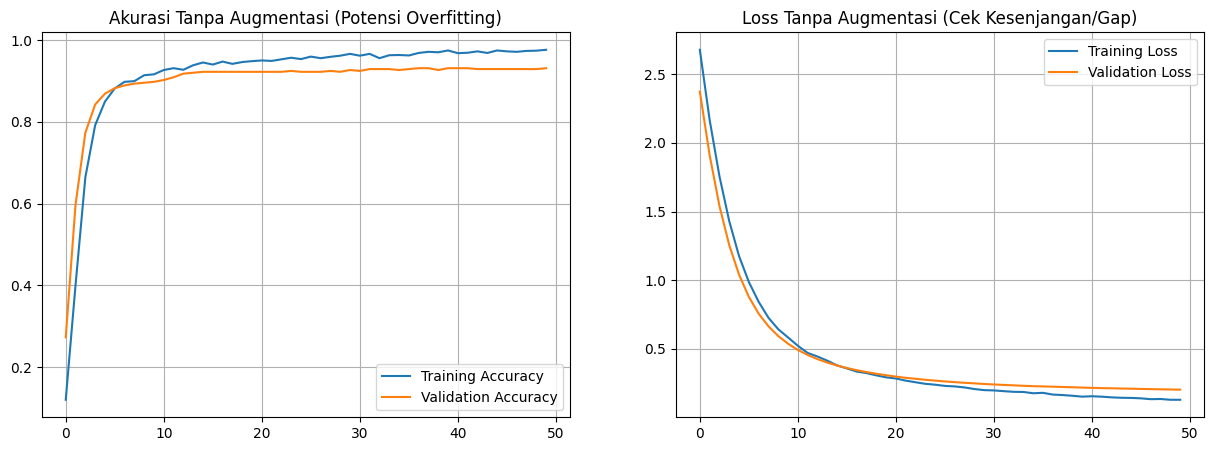

In [10]:
# ==========================================
# EKSPERIMEN: TANPA DATA AUGMENTATION (FIXED)
# ==========================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import tensorflow as tf

# Gunakan path folder yang sudah dibuat di Sel 2
base_dir = '/kaggle/working/dog_breed_selection' 

# 1. Generator Tanpa Augmentasi (Hanya Split Data)
no_aug_datagen = ImageDataGenerator(validation_split=0.2)

# 2. Persiapan Data Train & Validation
train_gen_no_aug = no_aug_datagen.flow_from_directory(
    base_dir, # Sekarang sudah terdefinisi
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen_no_aug = no_aug_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# 3. Build Model Baru menggunakan optimizer baru (instance terpisah)
print("\n--- Membangun Model EfficientNet-B0 (Tanpa Augmentasi) ---")
tf.keras.backend.clear_session() # Bersihkan memori sebelum eksperimen baru
model_no_aug = build_efficientnet_b0() 

model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Optimizer baru
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Pelatihan
history_no_aug = model_no_aug.fit(
    train_gen_no_aug,
    validation_data=val_gen_no_aug,
    epochs=50, 
    verbose=1
)

# 5. Visualisasi Perbandingan (Overfitting Plot)
acc = history_no_aug.history['accuracy']
val_acc = history_no_aug.history['val_accuracy']
loss = history_no_aug.history['loss']
val_loss = history_no_aug.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Tanpa Augmentasi (Potensi Overfitting)')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Tanpa Augmentasi (Cek Kesenjangan/Gap)')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

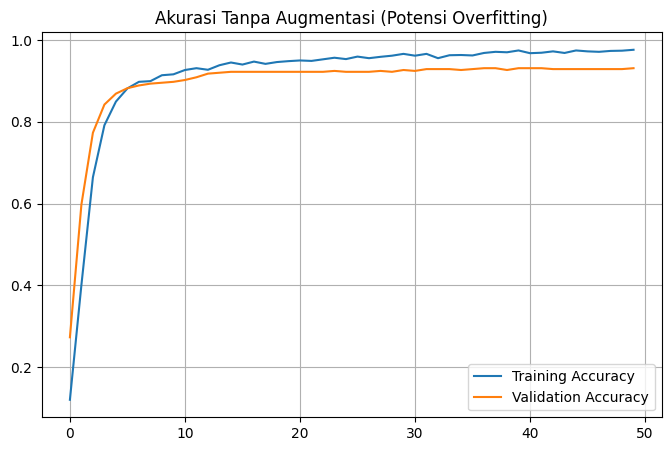

In [11]:
# 5. Visualisasi Perbandingan (Overfitting Plot)
acc = history_no_aug.history['accuracy']
val_acc = history_no_aug.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))

# Plot Akurasi
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Tanpa Augmentasi (Potensi Overfitting)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

Found 1800 images belonging to 15 classes.
Found 450 images belonging to 15 classes.

--- Membangun Model MobileNetV2 (Tanpa Augmentasi) ---
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 286ms/step - accuracy: 0.0857 - loss: 3.0003 - val_accuracy: 0.2556 - val_loss: 2.3233
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.2833 - loss: 2.2593 - val_accuracy: 0.5111 - val_loss: 1.7865
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.5149 - loss: 1.7265 - val_accuracy: 0.6644 - val_loss: 1.4019
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.6561 - loss: 1.3477 - val_accuracy: 0.7444 - val_loss: 1.1340
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7315 - loss: 1.1103 - val_accuracy: 0.7933 - val_loss: 0.9454
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.7795 - loss: 0.9182 - val_accuracy: 0.8111 - val_loss: 0.8164
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8107 - loss: 0.8069 - val_accu

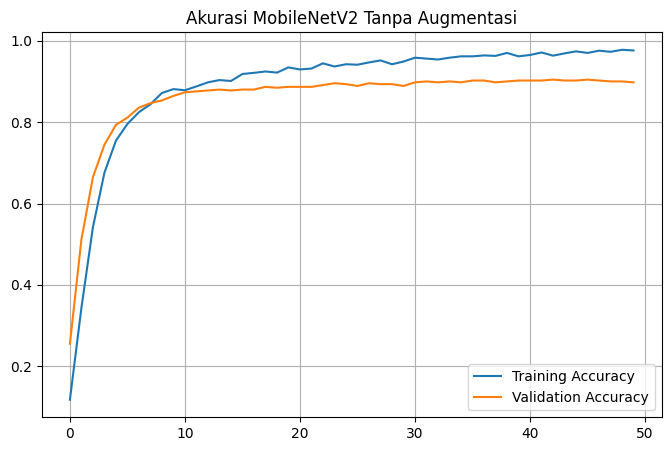

In [12]:
# ==========================================
# EKSPERIMEN: MOBILENETV2 TANPA AUGMENTASI (FIXED)
# ==========================================

# 1. Gunakan base_dir yang sudah terdefinisi (working_path dari Sel 2)
# base_dir = '/kaggle/working/dog_breed_selection' 

# 2. Generator Tanpa Augmentasi (Hanya Rescale & Split)
no_aug_mobile_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
)

# 3. Persiapan Data Train & Validation
train_gen_mobile_no_aug = no_aug_mobile_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42 # Konsisten dengan eksperimen sebelumnya
)

val_gen_mobile_no_aug = no_aug_mobile_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# 4. Build Model MobileNetV2 Baru
print("\n--- Membangun Model MobileNetV2 (Tanpa Augmentasi) ---")
# Gunakan clear_session agar memori GPU bersih
tf.keras.backend.clear_session() 
model_mobile_no_aug = build_mobilenet_v2() 

model_mobile_no_aug.compile(
    # Buat instance optimizer baru agar tidak error 'Unknown variable'
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Pelatihan
history_mobile_no_aug = model_mobile_no_aug.fit(
    train_gen_mobile_no_aug,
    validation_data=val_gen_mobile_no_aug,
    epochs=50, 
    verbose=1
)

# 5. Visualisasi Hasil
acc = history_mobile_no_aug.history['accuracy']
val_acc = history_mobile_no_aug.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi MobileNetV2 Tanpa Augmentasi')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [13]:
# ==========================================
# SEL: DOWNLOAD MODEL TERBAIK
# ==========================================

from IPython.display import FileLink
import os

# 1. Pastikan file model ada di folder /kaggle/working/
model_files = ['best_mobilenet.keras', 'best_efficientnet.keras']

print("Klik link di bawah ini untuk mengunduh model:")

for model_file in model_files:
    file_path = f'/kaggle/working/{model_file}'
    
    if os.path.exists(file_path):
        # Menghasilkan link unduhan langsung di notebook Kaggle
        display(FileLink(model_file))
    else:
        print(f"Peringatan: File {model_file} tidak ditemukan. Pastikan proses training sudah selesai.")

# Catatan: Jika Anda ingin mendownload model eksperimen (tanpa augmentasi), 
# pastikan Anda sudah menyimpannya dengan nama file yang berbeda sebelumnya.

Klik link di bawah ini untuk mengunduh model:


/kaggle/working/best_mobilenet.keras

/kaggle/working/best_efficientnet.keras

In [14]:
# Jalankan ini di Kaggle
model_mobilenet.save('model_k3_mobile.keras')
model_efficientnet.save('model_k3_eff.keras')